Using Batch Normalization with different activation function for MNIST dataset

In [6]:
# we are building the model using batch normalization with sigmoid
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from keras.constraints import maxnorm
from keras.layers import Activation
import numpy

In [2]:
# The “seed” is a starting point for the sequence and the guarantee is that if you start from the same seed you will get the same sequence of numbers.
seed = 21
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In [3]:
# we are reshaping the image by its pixels values such as samples width height and channels
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [4]:
# we are feature scaling the values into 0 and 1
X_train = X_train / 255
X_test = X_test / 255

In [5]:
# we are applying one hot encoding 
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [ ]:
# we are creating the CNN model 
def baseline_model():
	 # we are creating the model as sequential
 model = Sequential()
 model.add(Conv2D(32, (3, 3), input_shape=(28,28,1)))  # it is a convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Conv2D(32, (3, 3))) # it is a convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu'))
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it into the array of smaller size

 model.add(Conv2D(64,(3, 3))) # it is a convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Conv2D(64, (3, 3))) # it is a convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it into the array of smaller size

 model.add(Flatten()) # it simplifies the array and coverts it into one dimensional 

# Fully connected layer
 model.add(Dense(512)) # dense layers are regularly deeply connected neural network layers
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting
 model.add(Dense(10)) # dense layers are regularly deeply connected neural network layers

 model.add(Activation('sigmoid'))

	# we are compiling the model
 
 model.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
 return model

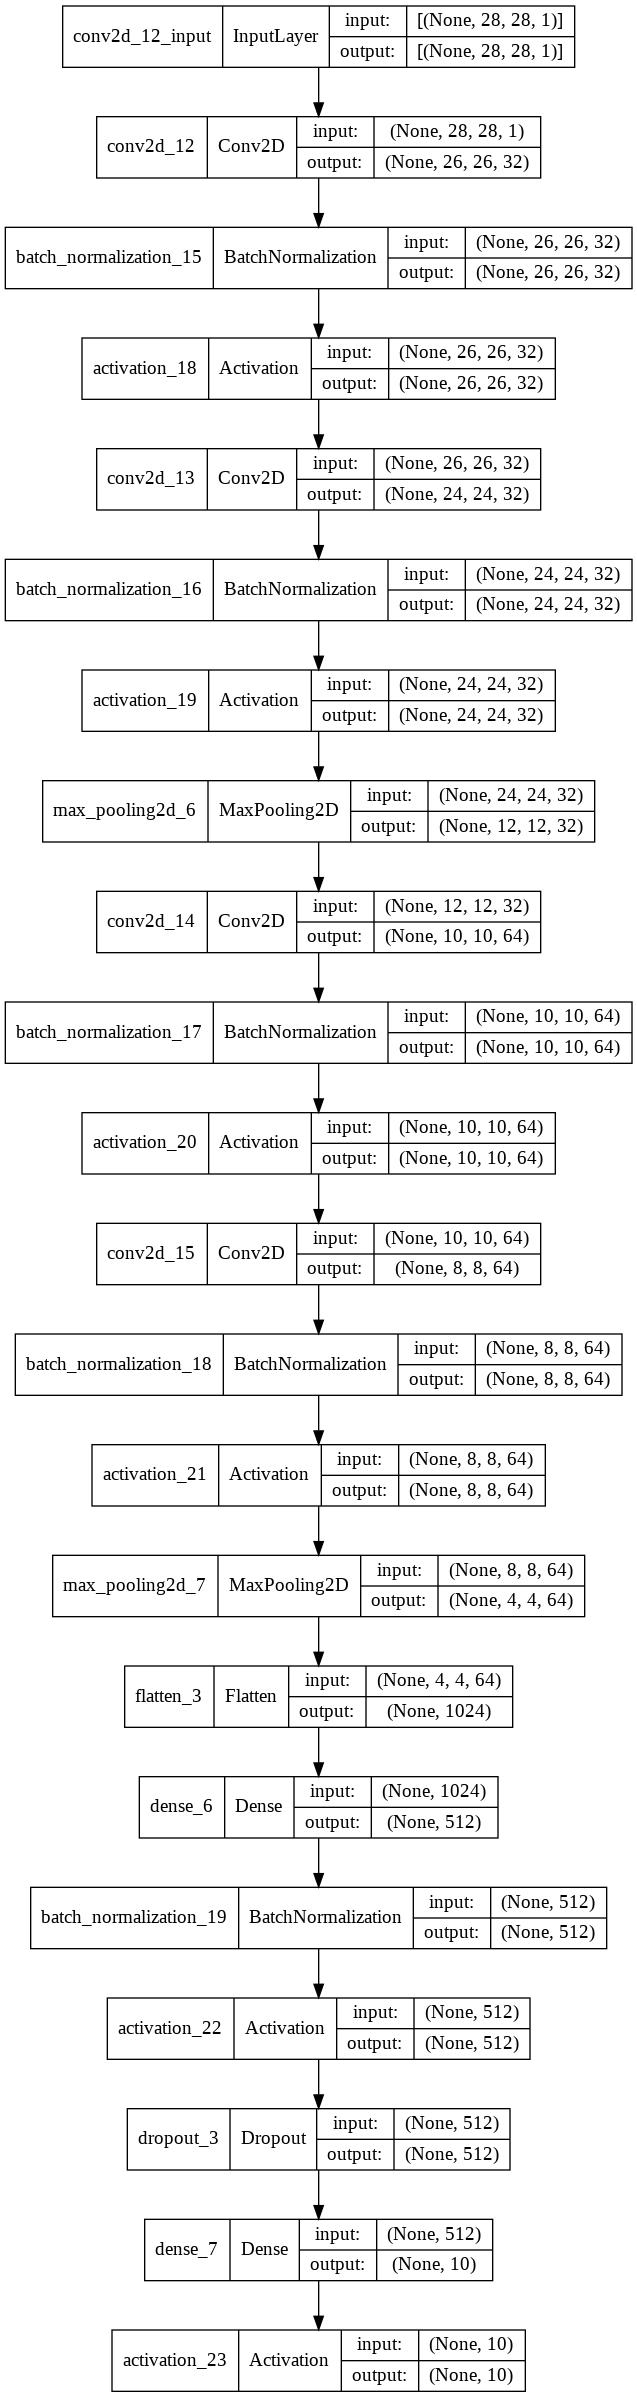

In [18]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [24]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=256)

Epoch 1/5
235/235 [==============================] - 173s 730ms/step - loss: nan - accuracy: 0.3058 - val_loss: nan - val_accuracy: 0.0980
Epoch 2/5
235/235 [==============================] - 173s 735ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 3/5
235/235 [==============================] - 206s 878ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 4/5
235/235 [==============================] - 198s 840ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 5/5
235/235 [==============================] - 190s 808ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980


we take epochs = 5 and batch size = 256 and got accuracy = 0.0987 
loss = nan

 we got cnn error as 90.20%

In [25]:
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))


CNN Error: 90.20%


In [26]:
#we are building the model using batch normalization with relu activation function
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from tensorflow.keras.utils import plot_model
from keras.utils import np_utils
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from tensorflow.keras.utils import plot_model
from tensorflow.keras.utils import to_categorical
from keras.constraints import maxnorm
from keras.layers import Activation
import numpy

In [27]:
# The “seed” is a starting point for the sequence and the guarantee is that if you start from the same seed you will get the same sequence of numbers.
seed = 21
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [28]:
# we are reshaping the model in terms of sample width height channel
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [29]:
# we are feature scaling here and converting our input to 0 and 1
X_train = X_train / 255
X_test = X_test / 255

In [30]:
# we are using one hot encoder
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [31]:
# we are creating the model
def baseline_model():
	# we are defining our model as sequential
 model = Sequential()
 model.add(Conv2D(32, (3, 3), input_shape=(28,28,1))) #it is convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Conv2D(32, (3, 3))) #it is convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it into the array of smaller size

 model.add(Conv2D(64,(3, 3))) #it is convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Conv2D(64, (3, 3))) #it is convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it into the array of smaller size

 model.add(Flatten()) # it simplifies the array and converts it to one dimensional

# Fully connected layer
 model.add(Dense(512)) # the network layer of neural has 512 nodes which are there
 model.add(BatchNormalization())
 model.add(Activation('relu'))
 model.add(Dropout(0.2)) # 20% of weights will be removed
 model.add(Dense(10))  # the output layer will have 10 nodes

 model.add(Activation('relu')) # the output layer has relu function

	# we are compiling the model
 
 model.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
 return model

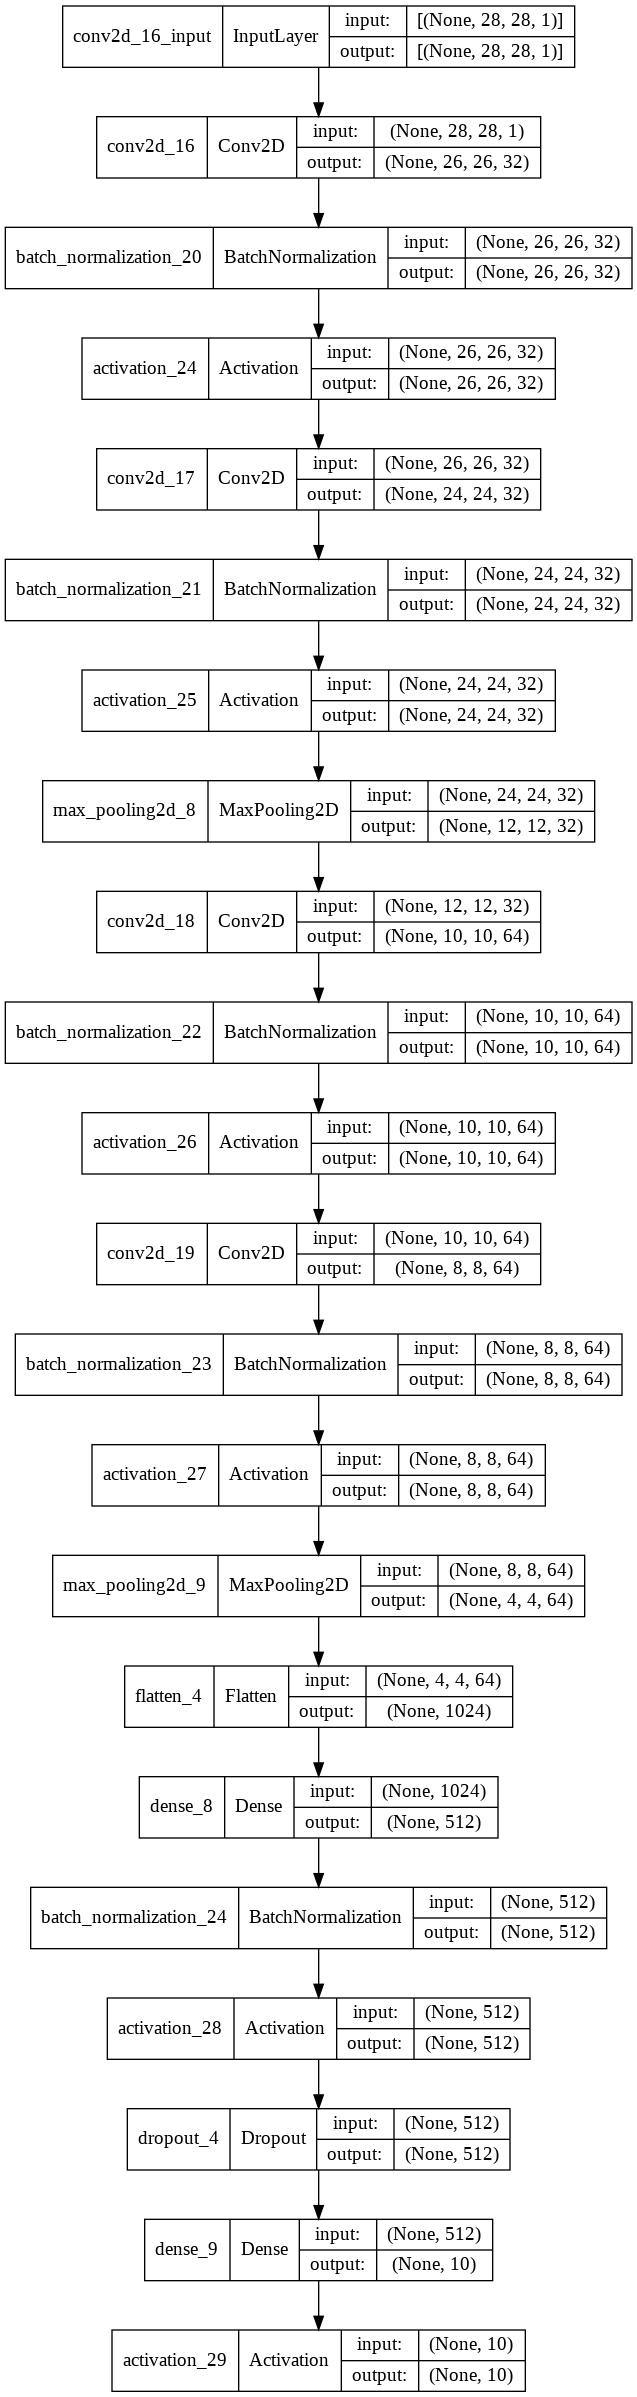

In [32]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [33]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=256)

Epoch 1/5
235/235 [==============================] - 222s 940ms/step - loss: nan - accuracy: 0.2474 - val_loss: nan - val_accuracy: 0.0980
Epoch 2/5
235/235 [==============================] - 199s 848ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 3/5
235/235 [==============================] - 195s 829ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 4/5
235/235 [==============================] - 222s 944ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 5/5
235/235 [==============================] - 197s 839ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980


 we took epochs = 5 and batch size = 256 and got accuracy = 0.0987 
 and loss = nan

we got cnn error 90.20%

In [34]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 90.20%


In [35]:
# we are building the model using batch normalization and elu activation function
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from tensorflow.keras.utils import plot_model
from tensorflow.keras.utils import to_categorical
from keras.constraints import maxnorm
from keras.layers import Activation
import numpy

In [36]:
# The “seed” is a starting point for the sequence and the guarantee is that if you start from the same seed you will get the same sequence of numbers.
seed = 21
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [37]:
# we are reshaping the image pixels as samples width height and channel
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [38]:
# we are feature scaling here and coverting the values to 0 and 1 for better accuracy
X_train = X_train / 255
X_test = X_test / 255

In [39]:
# we afre using one hot encoding here
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [40]:
# we are creating the model
def baseline_model():
	# we are defining our model as sequential
 model = Sequential()
 model.add(Conv2D(32, (3, 3), input_shape=(28,28,1))) #it is a convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Conv2D(32, (3, 3))) #it is a convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it into the array of smaller size

 model.add(Conv2D(64,(3, 3))) #it is a convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Conv2D(64, (3, 3))) #it is a convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it into the array of smaller size

 model.add(Flatten()) # it simplifies the array and converts it to one dimensional

# Fully connected layer 
 model.add(Dense(512)) # the network layer of neural has 512 nodes which are there
 model.add(BatchNormalization())
 model.add(Activation('relu'))
 model.add(Dropout(0.2)) # 20% of weights will be removed
 model.add(Dense(10)) # the output layer will have 10 nodes

 model.add(Activation('elu')) # the output layer has elu function

	# we are compiling the model
 
 model.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
 return model

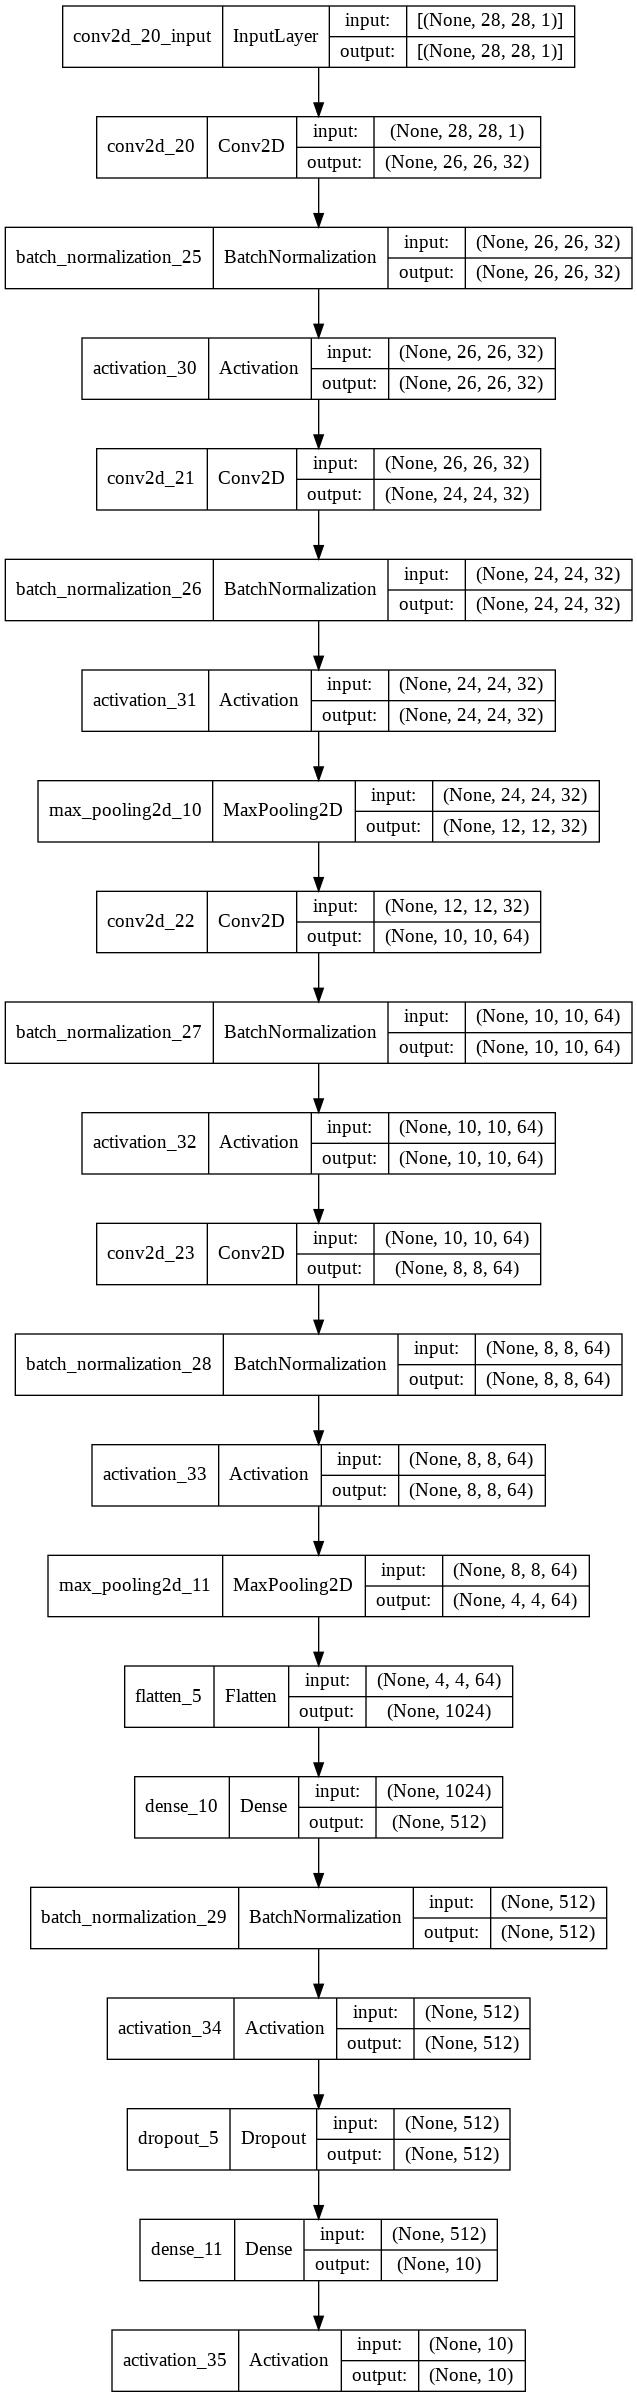

In [41]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [42]:
# we are training and evaluating our model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=256)

Epoch 1/5
235/235 [==============================] - 217s 922ms/step - loss: 6.6709 - accuracy: 0.4364 - val_loss: 10.0577 - val_accuracy: 0.1135
Epoch 2/5
235/235 [==============================] - 210s 894ms/step - loss: 6.6848 - accuracy: 0.4669 - val_loss: 8.3218 - val_accuracy: 0.2825
Epoch 3/5
235/235 [==============================] - 210s 895ms/step - loss: 7.0773 - accuracy: 0.4353 - val_loss: 7.9582 - val_accuracy: 0.3999
Epoch 4/5
235/235 [==============================] - 177s 752ms/step - loss: 7.7865 - accuracy: 0.4616 - val_loss: 7.2280 - val_accuracy: 0.5060
Epoch 5/5
235/235 [==============================] - 170s 722ms/step - loss: 7.3251 - accuracy: 0.5096 - val_loss: 7.1634 - val_accuracy: 0.5593


we take epochs = 5 batch size = 256 and got accuracy = 0.5096
loss = 7.3251

we got cnn error as 44.07%

In [43]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 44.07%


In [44]:
#we are building the model using batch normalization with selu activation function
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from tensorflow.keras.utils import plot_model
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from tensorflow.keras.utils import to_categorical
from keras.constraints import maxnorm
from keras.layers import Activation
import numpy

In [45]:
# The “seed” is a starting point for the sequence and the guarantee is that if you start from the same seed you will get the same sequence of numbers.
seed = 21
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [46]:
# we are reshaping the pixels of images such as sample width height and channel
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [47]:
# we are feature scaling and converting the input to 0 and 1 for better accuracy
X_train = X_train / 255
X_test = X_test / 255

In [48]:
# Using the method to_categorical(), a numpy array (or) a vector which has integers that represent different categories,
# can be converted into a numpy array (or) a matrix which has binary values and has columns equal to the number of categories in the data.
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [49]:
# we are building the model
def baseline_model():
	# we are defining the model as sequential
 model = Sequential()
 model.add(Conv2D(32, (3, 3), input_shape=(28,28,1))) # it is the convolutional operator for filtering windows of two dimensional input 
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Conv2D(32, (3, 3)))  # it is the convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it into the array of   smaller size

 model.add(Conv2D(64,(3, 3)))  # it is the convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(Conv2D(64, (3, 3)))  # it is the convolutional operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it into the array of   smaller size

 model.add(Flatten()) # it simplifies the array and converts it to one dimensional

# Fully connected layer
 model.add(Dense(512)) #  neural network layer has 512 nodes which are there
 model.add(BatchNormalization())
 model.add(Activation('relu')) 
 model.add(Dropout(0.2)) # 20% of weights will be removed 
 model.add(Dense(10)) # the output layer has 10 nodes 

 model.add(Activation('selu')) # the output layer will have selu activation function

	# we are compiling the model
 
 model.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
 return model

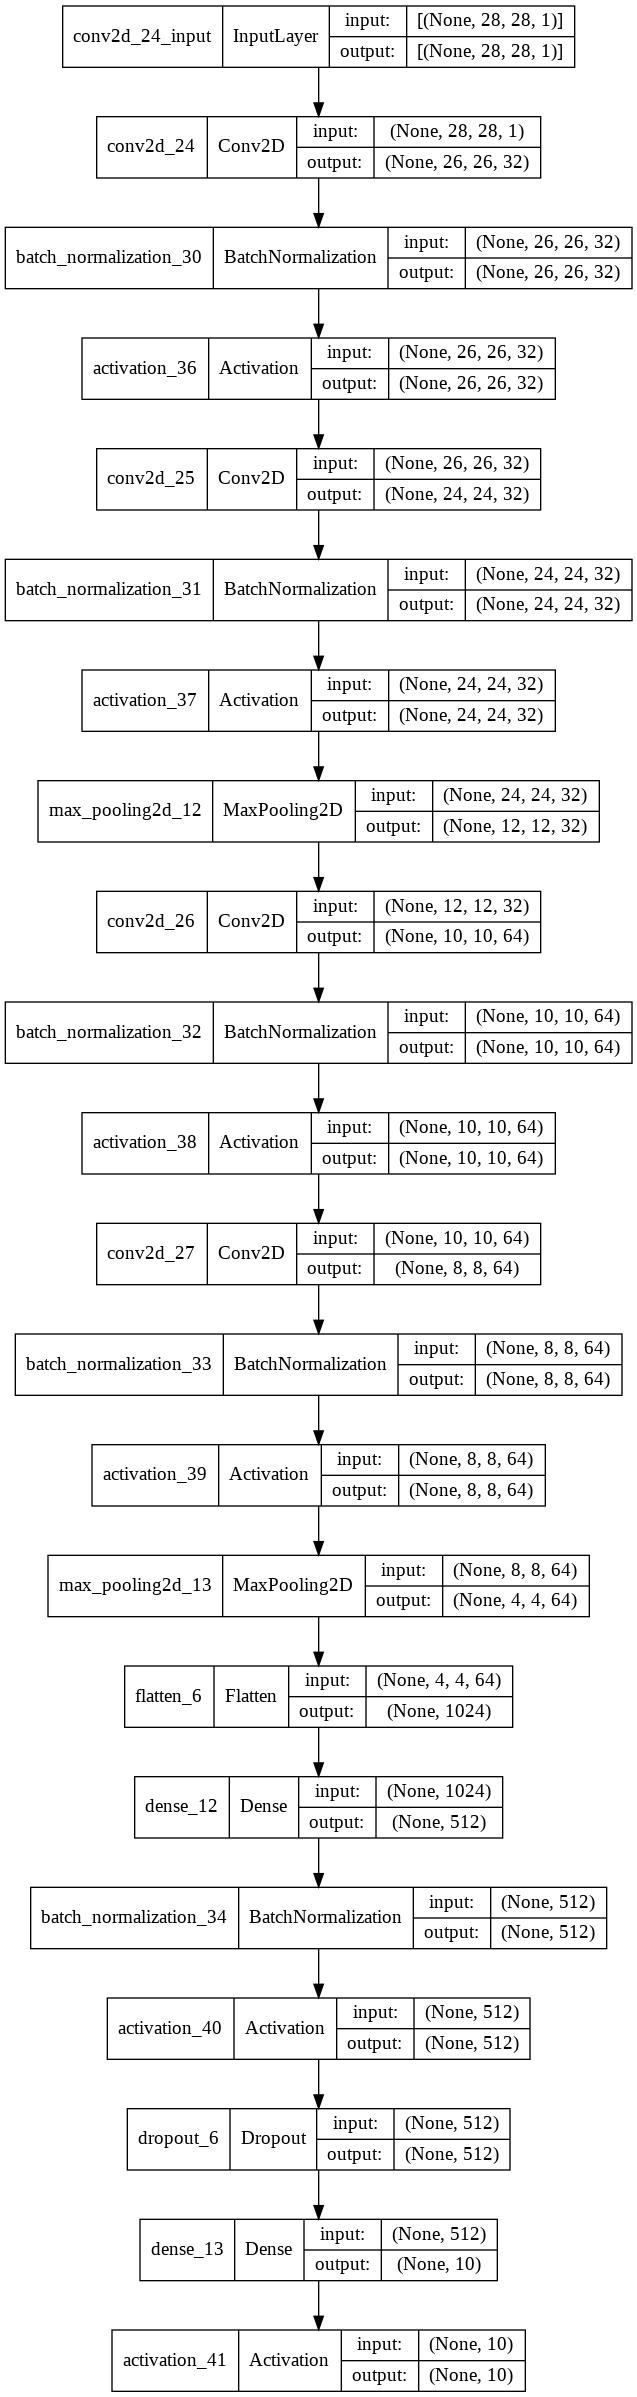

In [50]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [51]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=256)

Epoch 1/5
235/235 [==============================] - 172s 727ms/step - loss: 8.1011 - accuracy: 0.4243 - val_loss: 5.6648 - val_accuracy: 0.1135
Epoch 2/5
235/235 [==============================] - 171s 726ms/step - loss: 8.7651 - accuracy: 0.2728 - val_loss: 7.9291 - val_accuracy: 0.2751
Epoch 3/5
235/235 [==============================] - 169s 720ms/step - loss: 8.1340 - accuracy: 0.3602 - val_loss: 7.6470 - val_accuracy: 0.3313
Epoch 4/5
235/235 [==============================] - 170s 725ms/step - loss: 6.7845 - accuracy: 0.3897 - val_loss: 6.0193 - val_accuracy: 0.4527
Epoch 5/5
235/235 [==============================] - 169s 721ms/step - loss: 6.9468 - accuracy: 0.3928 - val_loss: 7.3616 - val_accuracy: 0.2316


we took 5 epochs and batch size =256 
got accuracy = 0.3928 and loss = 6.9468

we got cnn error = 76.84%

In [52]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))


CNN Error: 76.84%


In [53]:
#we are building the model using batch normalization wit tanh
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from tensorflow.keras.utils import to_categorical
from keras.constraints import maxnorm
from tensorflow.keras.utils import plot_model
from keras.layers import Activation
import numpy



In [54]:
# The “seed” is a starting point for the sequence and the guarantee is that if you start from the same seed you will get the same sequence of numbers.
seed = 21
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [55]:
# we are reshaping the image pixels such as sample width height and channel
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [56]:
# we are feature scaling the pixels in between 0 and 1 for better accuracy
X_train = X_train / 255
X_test = X_test / 255

In [57]:
# Using the method to_categorical(), a numpy array (or) a vector which has integers that represent different categories, can be converted
# into a numpy array (or) a matrix which has binary values and has columns equal to the number of categories in the data.
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [58]:
# we are building the model 
def baseline_model():
	# we are creating our model as sequential
 model = Sequential()
 model.add(Conv2D(32, (3, 3), input_shape=(28,28,1))) # it is convolutinal operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see whether the neurons are activated or not
 model.add(Conv2D(32, (3, 3)))  # it is convolutinal operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it to into the arrays of smaller size

 model.add(Conv2D(64,(3, 3)))  # it is convolutinal operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see whether the neurons are activated or not
 model.add(Conv2D(64, (3, 3)))  # it is convolutinal operator for filtering windows of two dimensional input
 model.add(BatchNormalization())
 model.add(Activation('relu')) # we will see whether the neurons are activated or not
 model.add(MaxPooling2D(pool_size=(2,2))) # it checks the maximum values and returns it to into the arrays of smaller size

 model.add(Flatten()) # it simpilifies the array and converts it into one dimensional 

# Fully connected layer
 model.add(Dense(512)) # neural network has 512 nodes which are there
 model.add(BatchNormalization())
 model.add(Activation('relu')) 
 model.add(Dropout(0.2)) # 20 % weights will be removed 
 model.add(Dense(10)) # the output layer ahs 10 nodes

 model.add(Activation('tanh')) # the output layer has tanh activation function

	# we are compiling the model
 
 model.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
 return model

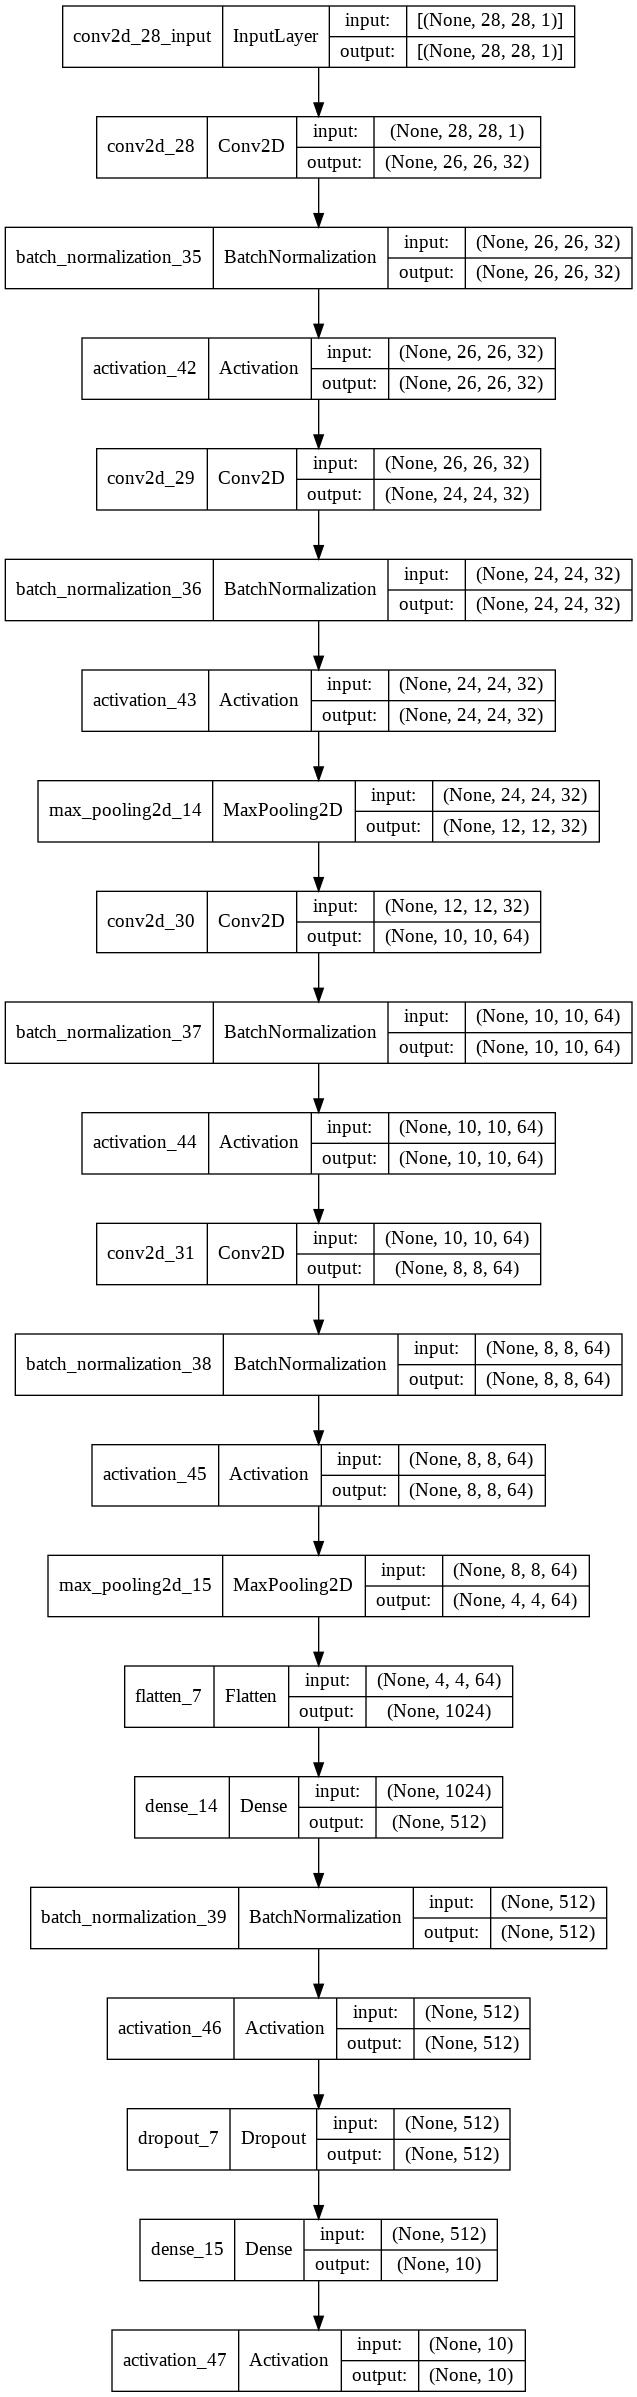

In [59]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [60]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=256)

Epoch 1/5
235/235 [==============================] - 173s 733ms/step - loss: 10.2951 - accuracy: 0.2799 - val_loss: 6.9533 - val_accuracy: 0.1135
Epoch 2/5
235/235 [==============================] - 171s 726ms/step - loss: 10.5658 - accuracy: 0.3823 - val_loss: 7.2283 - val_accuracy: 0.1166
Epoch 3/5
235/235 [==============================] - 170s 723ms/step - loss: 10.2232 - accuracy: 0.2925 - val_loss: 8.5221 - val_accuracy: 0.3541
Epoch 4/5
235/235 [==============================] - 169s 718ms/step - loss: 9.7794 - accuracy: 0.2326 - val_loss: 8.8703 - val_accuracy: 0.2092
Epoch 5/5
235/235 [==============================] - 168s 715ms/step - loss: 8.4697 - accuracy: 0.1288 - val_loss: 9.2057 - val_accuracy: 0.0415


we took epochs = 5 batch size = 256 got accuracy = 0.1288 
loss = 8.4697

we got cnn error 95.85%

In [61]:
# the final representaion of model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 95.85%
